## Skin Cancer Detection

This project implements a multimodal Convolutional Neural Network (CNN) to detect skin cancer. The model leverages both image data (dermatoscopic images of skin lesions) and tabular clinical data (age, sex, localization) to improve diagnostic accuracy. The goal is to develop a robust system that can assist in the early detection of melanoma and other skin cancers.

## Libraries import


In [1]:
# pip install keras

In [2]:
import cv2
from collections import defaultdict
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from glob import glob
import seaborn as sns
from PIL import Image
np.random.seed(1234)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from tqdm import tqdm
import itertools
import operator

import keras
from keras.utils import to_categorical
from keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPool2D, Dropout, Flatten,
    Dense, Concatenate, Activation
)
from tensorflow.keras.models import load_model
from keras import backend as K
import itertools
from keras.layers import BatchNormalization

from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [3]:
# import torch
# if torch.cuda.is_available():
#     device = "cuda"
# elif torch.backends.mps.is_available():
#     device = "mps"
# else:
#     device = "cpu"

# print(f"Using {device} device")

## Generic Methods Definition

In [4]:
def show_images_per_class(
    skin_df,
    n_per_class=5,
    label_col="cell_type",
    seed=42
):
    classes = sorted(skin_df[label_col].unique())
    n_classes = len(classes)

    fig, axes = plt.subplots(
        n_classes,
        n_per_class,
        figsize=(n_per_class * 3, n_classes * 3)
    )

    for row_idx, cls in enumerate(classes):
        class_df = skin_df[skin_df[label_col] == cls].sample(
            n=n_per_class,
            random_state=seed,
            replace=len(skin_df[skin_df[label_col] == cls]) < n_per_class
        )

        for col_idx, (_, row) in enumerate(class_df.iterrows()):
            img_path = get_image_path(row["image_id"])
            if img_path is None:
                axes[row_idx, col_idx].axis("off")
                continue

            img = Image.open(img_path).convert("RGB")
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis("off")

            # Título de la clase solo en la primera columna
            if col_idx == 0:
                axes[row_idx, col_idx].set_title(
                    cls,
                    fontsize=12,
                    loc="left",
                    pad=10
                )

    plt.tight_layout()
    plt.show()


In [5]:
def show_image_with_prediction(
    skin_df,
    idx,             # índice de la imagen a mostrar
    x_test,           # imágenes normalizadas para el modelo
    X_tab_test,       # data tabular de validación
    y_test,           # labels de validación
    model,
    label_col="cell_type"
):
    # Imagen para la predicción
    img_norm = x_test[idx]
    tab_data = X_tab_test[idx]
    label_true = y_test[idx]

    # Predicción
    prediction = model.predict([img_norm[np.newaxis, ...], tab_data[np.newaxis, ...]])
    pred_prob = prediction[0,0]

    # Cargar imagen original del archivo
    img_path = skin_df.iloc[idx]['path']
    img_original = Image.open(img_path).convert("RGB")

    # Mostrar imagen
    plt.figure(figsize=(4,4))
    plt.imshow(img_original)
    plt.axis("off")

    # Título con label y probabilidad
    # true_label_name = skin_df[label_col].iloc[idx]
    if y_val[idx] == 0:
        true_label_name = "Benign"
    else:
        true_label_name = "Malignant"
    plt.title(f"True: {true_label_name}\nPred prob malignancy: {pred_prob:.2f}", fontsize=12)
    plt.show()

## Load Dataset

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Download latest version, this is needed to be able to download images
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [8]:
drive_path = '/content/drive/MyDrive/skin_df_eda.xlsx'
skin_df = pd.read_excel(drive_path)

print("skin_df loaded successfully.\n")
display(skin_df.head())

# Ensure `is_malignant` is string type for ImageDataGenerator
skin_df['is_malignant_str'] = skin_df['is_malignant'].astype(str)

skin_df loaded successfully.



,lesion_id,image_id,dx_type,age,sex,localization,path,cell_type,cell_type_idx,is_malignant,image_hash
0,HAM_0000118,ISIC_0027419,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,34060fcaa8639d8bb0a4ed2039d53759
1,HAM_0000118,ISIC_0025030,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,e92f770c844315ac742ceefc3d9460dd
2,HAM_0002730,ISIC_0026769,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,968fb50ace9a1378e279b2e7b341f34f
3,HAM_0002730,ISIC_0025661,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,1e2f94fddad0005418e5fa7f35f65a46
4,HAM_0001466,ISIC_0031633,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/HAM10...,Benign keratosis-like lesions,2,False,9dfd09a56cce8b3dda485fe8805031ea


In [9]:
pd.set_option('display.max_colwidth', None)
skin_df["path"].head()

,path
0,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0027419.jpg
1,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025030.jpg
2,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0026769.jpg
3,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1/ISIC_0025661.jpg
4,/kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2/ISIC_0031633.jpg


In [10]:
skin_df['is_malignant'] = skin_df['is_malignant'].apply(lambda x: 1 if x in [True] else 0)
skin_df.is_malignant.value_counts()

,count
is_malignant,
0,8012
1,1954


# Preprocess the data

Images are loaded from disk, converted to RGB, resized to 100 × 75 pixels, and normalized to the
[0,1]
[0,1] range; samples with missing or invalid images are removed.

Tabular features (age, sex, localization) are extracted; missing age values are imputed using the median, and categorical variables are one-hot encoded.

Image data, tabular data, and binary labels are assembled into aligned multimodal arrays.

The dataset is split into training, validation, and test sets using index-based stratified sampling to preserve class balance and multimodal alignment.

Image inputs are standardized using training-set statistics only, preventing data leakage.

Tabular features are standardized with a StandardScaler fitted on the training set and applied to validation and test sets.

In [11]:
# ===============================
# Config
# ===============================
IMG_WIDTH = 100
IMG_HEIGHT = 75
RANDOM_STATE = 1234

# ===============================
# Image loading + resize
# ===============================
def load_and_resize_image(path):
    if pd.isna(path):
        return None
    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        img = np.asarray(img, dtype=np.float32) / 255.0
        return img
    except:
        return None

skin_df['image'] = skin_df['path'].apply(load_and_resize_image)
skin_df.dropna(subset=['image'], inplace=True)
skin_df.reset_index(drop=True, inplace=True)

# ===============================
# Tabular features
# ===============================
tab_df = skin_df[['age', 'sex', 'localization']].copy()

# NOTE: imputación previa (aceptable para experimento)
tab_df['age'] = tab_df['age'].fillna(tab_df['age'].median())
tab_df = pd.get_dummies(tab_df, columns=['sex', 'localization'], drop_first=True)

# ===============================
# Final arrays
# ===============================
X_img = np.stack(skin_df['image'].values)
X_tab = tab_df.values
y = skin_df['is_malignant'].astype(int).values

# ===============================
# Index-based split (safe for multimodal)
# ===============================
indices = np.arange(len(skin_df))

# Train / Test
idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Train / Validation
idx_train, idx_val = train_test_split(
    idx_train,
    test_size=0.1,
    random_state=RANDOM_STATE,
    stratify=y[idx_train]
)

# ===============================
# Build datasets
# ===============================
X_img_train = X_img[idx_train]
X_img_val   = X_img[idx_val]
X_img_test  = X_img[idx_test]

X_tab_train = X_tab[idx_train]
X_tab_val   = X_tab[idx_val]
X_tab_test  = X_tab[idx_test]

y_train = y[idx_train]
y_val   = y[idx_val]
y_test  = y[idx_test]

print("Images:", X_img_train.shape, X_img_val.shape, X_img_test.shape)
print("Tabular:", X_tab_train.shape, X_tab_val.shape, X_tab_test.shape)
print("Labels:", y_train.shape, y_val.shape, y_test.shape)

# ===============================
# Image normalization (NO leakage)
# ===============================
mean = X_img_train.mean()
std  = X_img_train.std()

x_train = (X_img_train - mean) / std
x_val   = (X_img_val   - mean) / std
x_test  = (X_img_test  - mean) / std

x_train = x_train.reshape(x_train.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)
x_val   = x_val.reshape(x_val.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)
x_test  = x_test.reshape(x_test.shape[0], IMG_HEIGHT, IMG_WIDTH, 3)

# ===============================
# Tabular normalization (NO leakage)
# ===============================
scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tab_train)
X_tab_val   = scaler.transform(X_tab_val)
X_tab_test  = scaler.transform(X_tab_test)


Images: (7174, 75, 100, 3) (798, 75, 100, 3) (1994, 75, 100, 3)
Tabular: (7174, 15) (798, 15) (1994, 15)
Labels: (7174,) (798,) (1994,)


# Model Training with images and tabular model

The model has two convolutional blocks.
The first block uses 32 filters to learn low-level features such as edges and textures, while the second block increases to 64 filters to capture more complex patterns. Each convolution is followed by batch normalization and ReLU activation, then max pooling to reduce spatial size and dropout to prevent overfitting.

After feature extraction, the network flattens the feature maps and uses a dense layer with 128 neurons to learn high-level representations, again with batch normalization, ReLU, and dropout.

Also have a tabular branch: processes structured variables (e.g., age, sex, localization) through a small dense layer to learn a compact representation of non-image information.

Then Fusion (Concatenation): combines visual and tabular features into a single representation, allowing the model to learn interactions between image patterns and clinical metadata.

Lastn, the network flattens the feature maps and uses a dense layer with 64 neurons to control model complexity and enforce an efficient fusion of information.

The final layer is a single sigmoid neuron, which outputs a probability for the positive class, making the model suitable for binary classification.



- 32 filters to capture simple, low-level features such as edges, color contrasts, and textures.
- the model increases the number of filters to 64 so it can learn more complex and abstract patterns (shapes, structures, lesion characteristics).

- Batch Normalization: normalizes activations to stabilize training, speed up convergence, and reduce overfitting.

- ReLU Activation: introduces non-linearity, allowing the network to learn complex patterns efficiently.

- Dense layer (128 neurons): combines extracted features into a high-level representation to support the final classification.





Final dense layers: refine the combined information and produce a probability output via a sigmoid activation for binary classification.

Using a small size like 8 neurons is a design choice that balances expressiveness and regularization, especially when the number of tabular features is limited.

It is reduced to 64 neurons after concatenation to control model complexity and enforce an efficient fusion of information. This design helps balance expressiveness and generalization in multimodal models.


In [12]:
IMG_HEIGHT = 75
IMG_WIDTH = 100
IMG_CHANNELS = 3

N_TAB_FEATURES = X_tab_train.shape[1]

EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 3e-4

IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

In [13]:
# ===============================
# Image branch
# ===============================

# Define IMG_SHAPE using previously defined dimensions


img_input = Input(shape=IMG_SHAPE, name="image_input")

x = Conv2D(32, (3,3), padding='same')(img_input)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(32, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.25)(x)

x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(64, (3,3), padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPool2D(2,2)(x)
x = Dropout(0.4)(x)

x = Flatten()(x)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.5)(x)

# ===============================
# Tabular branch (CONTROLADA)
# ===============================

tab_input = Input(shape=(X_tab_train.shape[1],), name="tabular_input")

t = Dense(8, activation='relu')(tab_input)
t = Dropout(0.2)(t)

# ===============================
# Fusion
# ===============================

combined = Concatenate()([x, t])

z = Dense(64, activation='relu')(combined)
z = Dropout(0.5)(z)

output = Dense(1, activation='sigmoid')(z)

model = Model(inputs=[img_input, tab_input], outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 75, 100,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 100,   │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 100,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 100,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 75, 100,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 100,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 75, 100,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 37, 50,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 37, 50,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 37, 50,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 50,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 37, 50,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 37, 50,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 50,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 37, 50,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 18, 25,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 18, 25,    │          0 │ max_pooling2d_1[

 Total params: 3,762,337 (14.35 MB)

 Trainable params: 3,761,697 (14.35 MB)

 Non-trainable params: 640 (2.50 KB)

In [14]:
# ===============================
# Compile
# ===============================

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# ===============================
# Class weights
# ===============================

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0,1]),
    y=y_train
)

class_weight = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weight)

# ===============================
# Callbacks
# ===============================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    mode='max',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

# ===============================
# Train

# ===============================

history = model.fit(
    [x_train, X_tab_train],
    y_train,
    validation_data=([x_val, X_tab_val], y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[lr_reduction, early_stop],
    verbose=1
)


Class weights: {0: np.float64(0.6219871683717704), 1: np.float64(2.549395877754087)}
Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 32s 76ms/step - auc: 0.6950 - loss: 0.6918 - recall: 0.6190 - val_auc: 0.7947 - val_loss: 0.5543 - val_recall: 0.8910 - learning_rate: 3.0000e-04
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - auc: 0.7895 - loss: 0.5177 - recall: 0.8003 - val_auc: 0.7968 - val_loss: 0.5683 - val_recall: 0.8846 - learning_rate: 3.0000e-04
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - auc: 0.8171 - loss: 0.4939 - recall: 0.8126 - val_auc: 0.8446 - val_loss: 0.4475 - val_recall: 0.7179 - learning_rate: 3.0000e-04
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - auc: 0.8341 - loss: 0.4840 - recall: 0.8140 - val_auc: 0.8393 - val_loss: 0.4848 - val_recall: 0.8333 - learning_rate: 3.0000e-04
Epoch 5/50
223/225 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc: 0.8475 - loss: 0.4763 - recall: 0.8316
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.

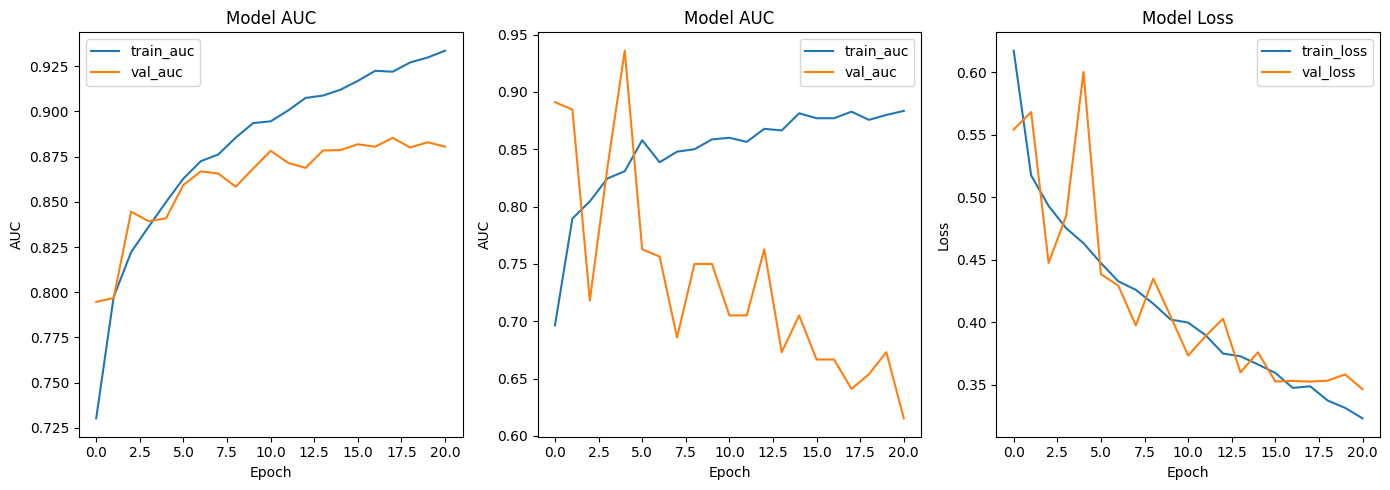

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

# AUC
axs[0].plot(history.history['auc'], label='train_auc')
axs[0].plot(history.history['val_auc'], label='val_auc')
axs[0].set_title('Model AUC')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('AUC')
axs[0].legend()

# Recall
axs[1].plot(history.history['recall'], label='train_auc')
axs[1].plot(history.history['val_recall'], label='val_auc')
axs[1].set_title('Model AUC')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('AUC')
axs[1].legend()

# Loss
axs[2].plot(history.history['loss'], label='train_loss')
axs[2].plot(history.history['val_loss'], label='val_loss')
axs[2].set_title('Model Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()

plt.tight_layout()
plt.show()


# Evalate model

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - auc: 0.9074 - loss: 0.3089 - recall: 0.6937
Test Loss   : 0.3117
Test AUC    : 0.9078
Test Recall : 0.6931
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Probabilities summary: min = 3.9444876e-07 mean = 0.25622165 max = 0.9878279
ROC AUC (sklearn): 0.9082


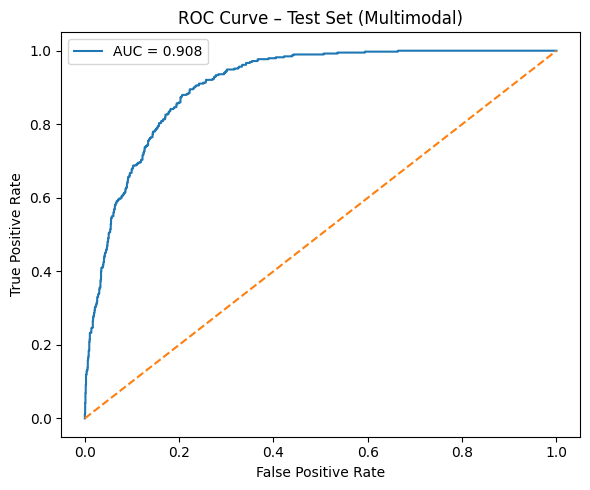

In [16]:
# ===============================
# Evaluate model (multimodal)
# ===============================
loss_test, auc_test, recall_test = model.evaluate(
    (x_test, X_tab_test),
    y_test,
    verbose=1
)

print(f"Test Loss   : {loss_test:.4f}")
print(f"Test AUC    : {auc_test:.4f}")
print(f"Test Recall : {recall_test:.4f}")

# ===============================
# Predict probabilities
# ===============================
y_test_prob = model.predict((x_test, X_tab_test), verbose=1).ravel()

print(
    "Probabilities summary:",
    "min =", np.min(y_test_prob),
    "mean =", np.mean(y_test_prob),
    "max =", np.max(y_test_prob)
)

# ===============================
# ROC AUC
# ===============================
auc_sklearn = roc_auc_score(y_test, y_test_prob)
print(f"ROC AUC (sklearn): {auc_sklearn:.4f}")

# ===============================
# ROC Curve
# ===============================
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_sklearn:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Test Set (Multimodal)")
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(['#da6b87',
                              '#7d233c', #rosa oscuro

                              '#cfbdb0', #beige oscuro

                              '#f1e6de'

                              ])

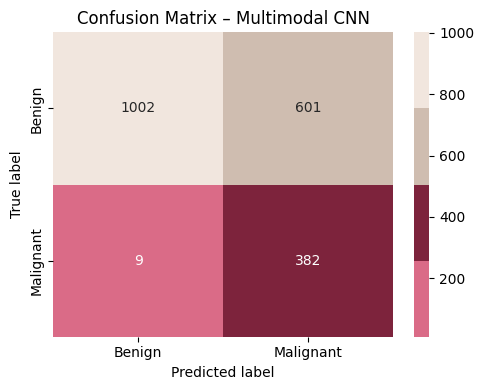

In [24]:
# ===============================
# Binary predictions (threshold)
# ===============================
threshold = 0.15
y_test_pred = (y_test_prob >= threshold).astype(int)

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=custom_cmap,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – Multimodal CNN')
plt.tight_layout()
plt.show()



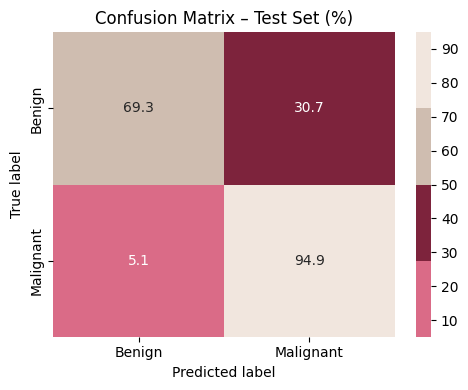

In [19]:
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap=custom_cmap,
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – Test Set (%)')
plt.tight_layout()
plt.show()


# Save Model

In [20]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/models/CIENCIA_DE_DATOS_UTEC/Trabajo_final/MIT_Workshop/Skin_Cancer_Detection/models/melanoma_multimodal_model_img.h5"

model.save(MODEL_PATH)
print(f"Model saved at: {MODEL_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved at: /content/drive/MyDrive/models/CIENCIA_DE_DATOS_UTEC/Trabajo_final/MIT_Workshop/Skin_Cancer_Detection/models/melanoma_multimodal_model_img.h5


In [21]:
# MODEL_PATH = "melanoma_multimodal_model_img.h5"

model.save(MODEL_PATH)
print(f"Model saved at: {MODEL_PATH}")

Model saved at: /content/drive/MyDrive/models/CIENCIA_DE_DATOS_UTEC/Trabajo_final/MIT_Workshop/Skin_Cancer_Detection/models/melanoma_multimodal_model_img.h5


# Some examples

In [22]:
# model_path = "melanoma_multimodal_model_img.h5"
model = load_model(MODEL_PATH)

1417
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 980ms/step


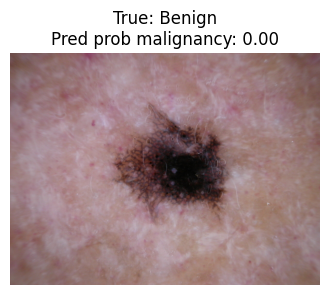

In [23]:
# Elegís el índice que quieras, por ejemplo:
idx = random.randint(0, x_test.shape[0] - 1)
print(idx) # 152

idx=152
show_image_with_prediction(
    skin_df=skin_df,
    idx=idx,
    x_test=x_test,
    X_tab_test=X_tab_test,
    y_test=y_test,
    model=model,
    label_col="cell_type"  # o "is_malignant" según tu dataframe
)
